In [28]:
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf = PyPDFLoader("Why_Language_Models_Hallucinate_Explainer.pdf")
document = pdf.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_overlap=120, chunk_size=1200)
pages = text_splitter.split_documents(documents=document)
chunks = [i.page_content for i in pages]

print(f"Total chunks: {len(chunks)}")

Total chunks: 10


In [29]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./Local_data")

collection = client.get_or_create_collection(
    name="edumind",
    embedding_function=embedding_function
)

if collection.count() == 0:
    collection.add(
        documents=chunks,
        ids=[str(i) for i in range(len(chunks))],
        metadatas=[i.metadata for i in pages]
    )

print(f"Collection size: {collection.count()}")

Collection size: 10


In [30]:
from rank_bm25 import BM25Okapi

def tokenize(text: str):
    return text.lower().split()

tokenized_chunks = [tokenize(c) for c in chunks]
corpus_build = BM25Okapi(tokenized_chunks)

In [31]:
from langchain_groq import ChatGroq
import os 
from dotenv import  load_dotenv 
load_dotenv()
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(model="openai/gpt-oss-120b")

In [32]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]
    context: str

In [33]:
def Retrival(state: State):
    query = state["messages"][-1].content

    response = collection.query(query_texts=[query], n_results=5)
    distances = response['distances'][0]
    documents = response['documents'][0]

    threshold = 0.8
    vector_chunks = [doc for dist, doc in zip(distances, documents) if dist < threshold]

    scores = corpus_build.get_scores(tokenize(query))
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    bm25_chunks = [chunks[i] for i, _ in ranked[:10]]   # bug fix: index -> actual text

    rrf_scores = {}
    for rank, doc in enumerate(vector_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)
    for rank, doc in enumerate(bm25_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)

    merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    top_docs = [doc for doc, _ in merged[:5]]

    context_text = "\n\n".join(top_docs) if top_docs else ""
    return {"context": context_text}

In [34]:
from langchain_core.tools import tool
from tavily import TavilyClient

@tool
def web_search(query: str):
    """Search the web when the document context is insufficient to answer."""
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = client.search(query=query)
    return str(response)


import numexpr
@tool
def calculator(expression: str):
    """Evaluate a math expression, e.g. '47 * 12'."""
    try:
        result = numexpr.evaluate(expression).item()
        return str(result)
    except Exception as e:
        return f"Error: {e}"

tools = [web_search, calculator]
tool_blind = chat_model.bind_tools(tools)

In [35]:
def agent(state=State):
    return {"messages": tool_blind.invoke(state['messages'])}

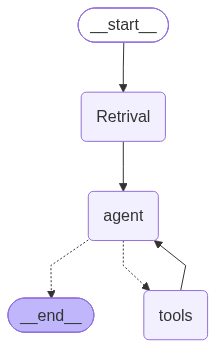

In [36]:
from langgraph.prebuilt import ToolNode, tools_condition

graph = StateGraph(State)
graph.add_node("Retrival", Retrival)
graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "Retrival")
graph.add_edge("Retrival", "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")

response = graph.compile()
response

In [37]:
result = response.invoke({
    "messages": [HumanMessage(content="What is full form of LLM ?")],
    "context": ""
})
print(result['messages'][-1].content)

Batches: 100%|██████████| 1/1 [00:00<00:00,  5.75it/s]


[08/21/26 20:35:36] INFO     HTTP Request: POST https://api.groq.com/openai/v1/chat/completions     _client.py:1025
                             "HTTP/1.1 200 OK"                                                                     

**LLM** can stand for different things depending on the context:

| Context | Full Form | What it means |
|---------|-----------|----------------|
| **Artificial Intelligence / Machine Learning** | **Large Language Model** | A type of neural‑network model (like GPT‑4, Claude, LLaMA, etc.) that has been trained on massive amounts of text data to understand and generate human‑like language. |
| **Legal Education** | **Master of Laws** (from the Latin *Legum Magister* / *Legum Magistra*) | A postgraduate academic degree for lawyers and law graduates who wish to specialize in a particular area of law or gain an international qualification. |

So, in most AI‑related discussions, **LLM = Large Language Model**. If you’re talking about law school or legal credentials, **LLM = Master of Laws**.


> SERVER

In [38]:
# only this mcp valid 
!uv pip install "mcp==1.9.4"

Resolved 20 packages in 37ms                                         
Uninstalled 1 package in 11ms
Installed 1 package in 9ms                                  
 - mcp==1.29.0
 + mcp==1.9.4


In [39]:
from mcp.server.fastmcp import FastMCP
mcp = FastMCP(name="edumind")

import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf = PyPDFLoader("Why_Language_Models_Hallucinate_Explainer.pdf")
document = pdf.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_overlap=120, chunk_size=1200)
pages = text_splitter.split_documents(documents=document)
chunks = [i.page_content for i in pages]

print(f"Total chunks: {len(chunks)}")


import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="./Local_data")

collection = client.get_or_create_collection(
    name="edumind",
    embedding_function=embedding_function
)

if collection.count() == 0:
    collection.add(
        documents=chunks,
        ids=[str(i) for i in range(len(chunks))],
        metadatas=[i.metadata for i in pages]
    )

print(f"Collection size: {collection.count()}") 

from rank_bm25 import BM25Okapi

def tokenize(text: str):
    return text.lower().split()

tokenized_chunks = [tokenize(c) for c in chunks]
corpus_build = BM25Okapi(tokenized_chunks)

from sentence_transformers import CrossEncoder 
from langchain_groq import ChatGroq
import os 
from dotenv import  load_dotenv 
load_dotenv()
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(model="openai/gpt-oss-120b")

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# rewritten_query
@mcp.tool()
def Retrival(query:str):
    prompt = f""" make the prompt contextual : {query} """
    rewritten_query = chat_model.invoke(prompt).content

    response = collection.query(query_texts=[rewritten_query], n_results=5)
    distances = response['distances'][0]
    documents = response['documents'][0]

    threshold = 0.8
    vector_chunks = [doc for dist, doc in zip(distances, documents) if dist < threshold]

    scores = corpus_build.get_scores(tokenize(rewritten_query))
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    bm25_chunks = [chunks[i] for i, _ in ranked[:10]]   # bug fix: index -> actual text

    rrf_scores = {}
    for rank, doc in enumerate(vector_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)
    for rank, doc in enumerate(bm25_chunks):
        rrf_scores[doc] = rrf_scores.get(doc, 0) + 1 / (rank + 60)

    merged = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    top_docs = [doc for doc, _ in merged[:5]]

    pairs = [(rewritten_query, doc) for doc in top_docs]
    reranker_scores = reranker.predict(pairs)
    reranked = [doc for _, doc in sorted(zip(scores, top_docs), reverse=True)]
    top_docs = reranked

    context_text = "\n\n".join(top_docs) if top_docs else ""
    return {"context": context_text}

import numexpr
@mcp.tool()
def calculator(expression:str):
    """ anytypes of aithmetic oparations is done by this tool """ 
    try : 
        return str(numexpr.evaluate(expression).item())
    except Exception as e :
        return str(e)

from tavily import TavilyClient

@mcp.tool()
def web_search(query:str)->str:
    """ user qustions fallback to this tool """ 
    client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = client.search(query=query)
    return str(response)


import os 
@mcp.tool()
def file_read(filename:str): 
    """ user given filename content read by this tool """
    try:
        with open (file=filename) as f :
            return f"content is : {f.read()}"
    except Exception as e:
        return str(e)
@mcp.tool()
def file_write(filename:str ,content:str):
    """ user given file path read the content if file doesnt exist then create and write the content """
    os.makedirs(os.path.dirname(os.path.abspath(filename)),exist_ok=True) 
    try: 
        with open (file=filename , mode="w") as file :
            content_write= file.write(content)
            return f"sucessfull {content_write}"
    except Exception as e :
        return str(e)

# if __name__ == "__main__":
#     mcp.run()

Total chunks: 10
Collection size: 10


[08/21/26 20:35:37] INFO     No device provided, using mps                                             model.py:199

[08/21/26 20:35:38] INFO     HTTP Request: HEAD                                                     _client.py:1025
                             https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/ma                
                             in/modules.json "HTTP/1.1 307 Temporary Redirect"                                     

                    INFO     HTTP Request: HEAD                                                     _client.py:1025
                             https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/mai                
                             n/modules.json "HTTP/1.1 404 Not Found"                                               

                    INFO     No modules.json found for cross-encoder/ms-marco-MiniLM-L-6-v2,          model.py:1069
                             initializing a new CrossEncoder model.                                                

...

                    INFO     HTTP Request: HEAD                                                     _client.py:1025
                             https://huggingface.co/api/resolve-cache/models/cross-encoder/ms-marco                
                             -MiniLM-L6-v2/233902d25c440f23af6f7d6e94d2946bac0bee0a/tokenizer_confi                
                             g.json "HTTP/1.1 200 OK"                                                              

[08/21/26 20:35:46] INFO     HTTP Request: GET                                                      _client.py:1025
                             https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2                
                             /tree/main/additional_chat_templates?recursive=false&expand=false                     
                             "HTTP/1.1 307 Temporary Redirect"                                                     

                    INFO     HTTP Request: GET                                                      _client.py:1025
                             https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2/                
                             tree/main/additional_chat_templates?recursive=false&expand=false                      
                             "HTTP/1.1 404 Not Found"                                                              

                    INFO     HTTP Request: GET                                                      _client.py:1025
                             https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2                
                             /tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary                        
                             Redirect"                                                                             

[08/21/26 20:35:47] INFO     HTTP Request: GET                                                      _client.py:1025
                             https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2/                
                             tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"                               

In [40]:
Retrival("what causes hallucination")

[08/21/26 20:35:51] INFO     HTTP Request: POST https://api.groq.com/openai/v1/chat/completions     _client.py:1025
                             "HTTP/1.1 200 OK"                                                                     

Batches: 100%|██████████| 1/1 [00:00<00:00,  4.96it/s]


{'context': "generation for high-stakes domains such as medicine and law.\n7. Takeaways\n- Hallucination is a predictable statistical outcome of current training and evaluation norms, not an\n unexplained defect.\n- Some hallucination is mathematically unavoidable for facts seen only once in training, regardless of\n model scale.\n- Post-training reduces certain error classes but cannot fully remove hallucination while benchmarks\n reward confident guessing over calibrated uncertainty.\n- Mitigation is most effective as a layered strategy — retrieval grounding, calibration, and evaluation\n reform together — rather than any single fix.\n- The failure mode is not confined to chatbots: it has already produced fabricated citations in\n peer-reviewed venues, government reports, and paid professional work.\nREFERENCES\n[1] Kalai, A. T., Nachum, O., Vempala, S. S., and Zhang, E. Why Language Models Hallucinate. arXiv:2509.04664,\n 2025.\n[2] Kalai, A. T. and Vempala, S. S. Calibrated Languag

In [41]:
calculator("47*12")

'564'

In [42]:
web_search("test query")

'{\'query\': \'test query\', \'follow_up_questions\': None, \'answer\': None, \'images\': [], \'results\': [{\'url\': \'https://github.com/danicat/testquery\', \'title\': \'GitHub - danicat/testquery: Test query is a command line tool to query test ...\', \'content\': "This tool was designed to make extracting information from tests easier for the average developer (as long as you know SQL of course - but everyone should learn SQL anyway ^^).\\n\\nIt is currently under development so it doesn\'t support a lot of information yet, but it is already possible to query basic information about tests, including: [...] # TestQuery\\n\\nTest Query (tq) is a command line tool to query Go test results with a SQL interface. The idea of using SQL was inspired by a similar tool called OSQuery, which does the same for operating system metrics.\\n\\n## Demo\\n\\n  demo01.mp4  \\n\\n## History [...] `make test-cover`: The primary test target. It runs both `unit-test` and `integration-test`, and then me

In [43]:
file_write("test.txt", "hello")

'sucessfull 5'

> Client 

In [59]:
from langchain.agents import create_agent 
from langchain_mcp_adapters.client import MultiServerMCPClient 
import os 
from dotenv import load_dotenv 
load_dotenv()
from langchain_groq import ChatGroq 
key = os.getenv("GROQ_API_KEY")
chat_model = ChatGroq(model="openai/gpt-oss-120b")

async def main():
    client = MultiServerMCPClient({
        "edumind_mcp":{
            "command":"python",
            "args":["server.py"],
            "transport":"stdio"
        }
    })
    get_tools = await client.get_tools() 
    if not get_tools:
        print("tools cant find out")
    LLM_blind = chat_model.bind_tools(get_tools) 

    agent = create_agent(model=LLM_blind,tools=get_tools,system_prompt="YOU are a realiable ai assistent for This MCP server so do the work sufficiently one by one using tool")

    query = "what is the largest country in the world right now ?"
    response = await agent.ainvoke({'messages':[('user',query)]})
    print(response['messages'][-1].content)

import asyncio 

if __name__ == "__main__":
    asyncio.run(main())



ImportError: cannot import name 'ElicitationFnT' from 'mcp.client.session' (/Users/debajyotihazra/Documents/AI-Powered Academic Research & Decision Intelligence Platform/.venv/lib/python3.12/site-packages/mcp/client/session.py)